[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Shape: (31962, 3)
   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation

Accuracy: 95.03 %

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.92      0.33      0.49       456

    accuracy                           0.95      6393
   macro avg       0.93      0.67      0.73      6393
weighted avg       0.95      0.95      0.94      6393



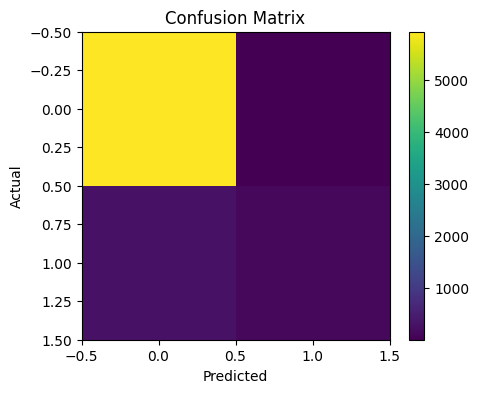


Sample Predictions:

Tweet 1: Positive/Normal 😊
Tweet 2: Positive/Normal 😊


In [9]:
# =========================
# TWITTER SENTIMENT ANALYSIS
# =========================

# Install and import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv('/content/twitter.csv')

print("Dataset Shape:", df.shape)
print(df.head())

# =========================
# DATA CLEANING
# =========================

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_tweet'] = df['tweet'].apply(clean_text)

# =========================
# FEATURES & LABELS
# =========================

X = df['clean_tweet']
y = df['label']

# =========================
# TEXT VECTORIZATION
# =========================

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# MODEL TRAINING
# =========================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================

y_pred = model.predict(X_test)

# =========================
# ACCURACY
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# CUSTOM TESTING
# =========================

def predict_sentiment(tweet):

    tweet = clean_text(tweet)

    vector = vectorizer.transform([tweet])

    prediction = model.predict(vector)[0]

    if prediction == 0:
        return "Positive/Normal 😊"
    else:
        return "Negative/Hate Speech 😡"

# =========================
# SAMPLE TESTS
# =========================

print("\nSample Predictions:\n")

print("Tweet 1:",
      predict_sentiment("I love this beautiful day"))

print("Tweet 2:",
      predict_sentiment("I hate everyone and everything"))